# 03 · Pathway enrichment

**Goal:** go from single genes to **biological processes**. Notebook 02 gave us thousands of genes. Here we ask: which *groups* of genes that work together (pathways) are switched on or off in liver tumors?

Two complementary methods:

| Method | Input | Question |
|---|---|---|
| **GSEA** (gene set enrichment analysis) | *all* genes, ranked from most up to most down in tumor | Are the genes of a pathway bunched at the top or bottom of the ranking? |
| **ORA** (over-representation analysis) | only our *significant* robust genes | Does a pathway appear in our gene list more often than expected by chance? |

Gene set collections:
- **MSigDB Hallmark** (50 pathways): a clean, non-redundant summary of major biological processes. Used for GSEA.
- **Reactome** (~1,800 pathways): detailed, specific pathways. Used for ORA.

> Gene sets are downloaded once from Enrichr and saved in `data/raw/genesets/`, so later runs work offline.

In [1]:
import os, sys, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gseapy as gp

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from src import data

FIG = ROOT / "figures"
RES = ROOT / "results"
GENESETS = data.RAW / "genesets"
GENESETS.mkdir(parents=True, exist_ok=True)

N_CPUS = max(1, (os.cpu_count() or 2) - 1)
sns.set_theme(style="whitegrid", context="notebook")

FDR = 0.05          # significance for pathways, decided in advance
PADJ, LFC = 0.05, 1.0   # same gene thresholds as notebook 02
print("gseapy", gp.__version__)

gseapy 1.3.1


## 1. Load differential expression results from notebook 02

We use **run A** (all samples) for the ranking, and runs A + B for the robust gene lists.

In [2]:
res_all = pd.read_csv(RES / "de_all_samples.csv.gz", index_col=0)
res_paired = pd.read_csv(RES / "de_paired.csv.gz", index_col=0)

def sig(res, direction):
    s = res["padj"] < PADJ
    return set(res.index[s & (res["log2FC"] > LFC)] if direction == "up" else res.index[s & (res["log2FC"] < -LFC)])

robust_up = sig(res_all, "up") & sig(res_paired, "up")
robust_down = sig(res_all, "down") & sig(res_paired, "down")

# gene sets use gene symbols, not Ensembl IDs
up_genes = sorted(res_all.loc[list(robust_up), "gene"].dropna().unique())
down_genes = sorted(res_all.loc[list(robust_down), "gene"].dropna().unique())
background = sorted(res_all["gene"].dropna().unique())      # every gene we tested

print(f"Robust up: {len(up_genes):,} | robust down: {len(down_genes):,} | background: {len(background):,}")

Robust up: 1,840 | robust down: 1,261 | background: 22,094


## 2. Download the gene set collections

A gene set is just a named list of genes, e.g. `"G2-M Checkpoint": ["CDK1", "CCNB1", ...]`.

In [3]:
def load_library(candidates):
    """Load the first available Enrichr library from a list of names (cached locally)."""
    for name in candidates:
        path = GENESETS / f"{name}.json"
        if path.exists():
            lib = json.loads(path.read_text())
        else:
            try:
                lib = gp.get_library(name=name, organism="Human")
            except Exception as e:
                print(f"  could not download {name}: {e}")
                continue
            path.write_text(json.dumps(lib))
        print(f"{name}: {len(lib)} gene sets")
        return name, lib
    raise RuntimeError(f"None of these libraries could be loaded: {candidates}")

HALLMARK_NAME, hallmark = load_library(["MSigDB_Hallmark_2020"])
REACTOME_NAME, reactome = load_library(["Reactome_Pathways_2024", "Reactome_2022"])

MSigDB_Hallmark_2020: 50 gene sets
  could not download Reactome_Pathways_2024: 'charmap' codec can't encode character '\u03b5' in position 46: character maps to <undefined>
Reactome_2022: 1816 gene sets


## 3. GSEA on Hallmark pathways

**Ranking:** every gene gets a score from DESeq2 (the Wald statistic `stat`). Big positive = confidently up in tumor, big negative = confidently down. We sort all ~22,000 genes by this score.

**GSEA** walks down the ranked list for each pathway. If the pathway's genes pile up near the top, the pathway is **activated** in tumors (positive NES). Near the bottom → **suppressed** (negative NES).

- **NES** (normalized enrichment score): direction and strength
- **FDR**: how likely the result is a fluke (after testing 50 pathways)

The p-values come from shuffling genes 1,000 times, so this takes a minute.

In [4]:
rank = (res_all.dropna(subset=["gene", "stat"])
        .assign(abs_stat=lambda d: d["stat"].abs())
        .sort_values("abs_stat", ascending=False)
        .drop_duplicates("gene")              # a few symbols map to 2 Ensembl IDs: keep the stronger one
        .set_index("gene")["stat"]
        .sort_values(ascending=False))
print(f"Ranked genes: {len(rank):,}")
print("Top of ranking:   ", ", ".join(rank.index[:8]))
print("Bottom of ranking:", ", ".join(rank.index[-8:]))

Ranked genes: 22,094
Top of ranking:    GABRD, PLVAP, CDKN3, CDC25C, UBE2T, NUF2, CENPF, SKA1
Bottom of ranking: ANGPTL6, ECM1, MAP2K1, CSRNP1, CCL23, STAB2, OIT3, ADAMTS13


In [5]:
%%time
gsea = gp.prerank(rnk=rank, gene_sets=hallmark, min_size=15, max_size=500,
                  permutation_num=1000, threads=N_CPUS, seed=42, outdir=None, verbose=False)

hall = gsea.res2d.copy()
for c in ["ES", "NES", "NOM p-val", "FDR q-val", "FWER p-val"]:
    hall[c] = pd.to_numeric(hall[c])
hall = hall.sort_values("NES", ascending=False).reset_index(drop=True)
hall.to_csv(RES / "gsea_hallmark.csv", index=False)

n_up = ((hall["FDR q-val"] < FDR) & (hall["NES"] > 0)).sum()
n_down = ((hall["FDR q-val"] < FDR) & (hall["NES"] < 0)).sum()
print(f"Hallmark pathways at FDR < {FDR}: {n_up} activated, {n_down} suppressed in tumor")
hall[["Term", "NES", "NOM p-val", "FDR q-val"]].round(4)

Hallmark pathways at FDR < 0.05: 7 activated, 24 suppressed in tumor
CPU times: total: 24.4 s
Wall time: 5.7 s


,Term,NES,NOM p-val,FDR q-val
0,E2F Targets,2.7754,0.0000,0.0000
1,G2-M Checkpoint,2.6605,0.0000,0.0000
2,Mitotic Spindle,1.8436,0.0000,0.0002
3,Spermatogenesis,1.8085,0.0000,0.0002
4,Myc Targets V1,1.5605,0.0000,0.0133
5,Wnt-beta Catenin Signaling,1.5202,0.0265,0.0175
6,Myc Targets V2,1.4365,0.0308,0.0386
7,DNA Repair,1.3282,0.0310,0.1161
8,Apical Junction,1.3135,0.0244,0.1226
9,Glycolysis,1.1136,0.2384,0.5889


### Hallmark summary plot

Red = activated in tumor, blue = suppressed. Faded bars are not significant.

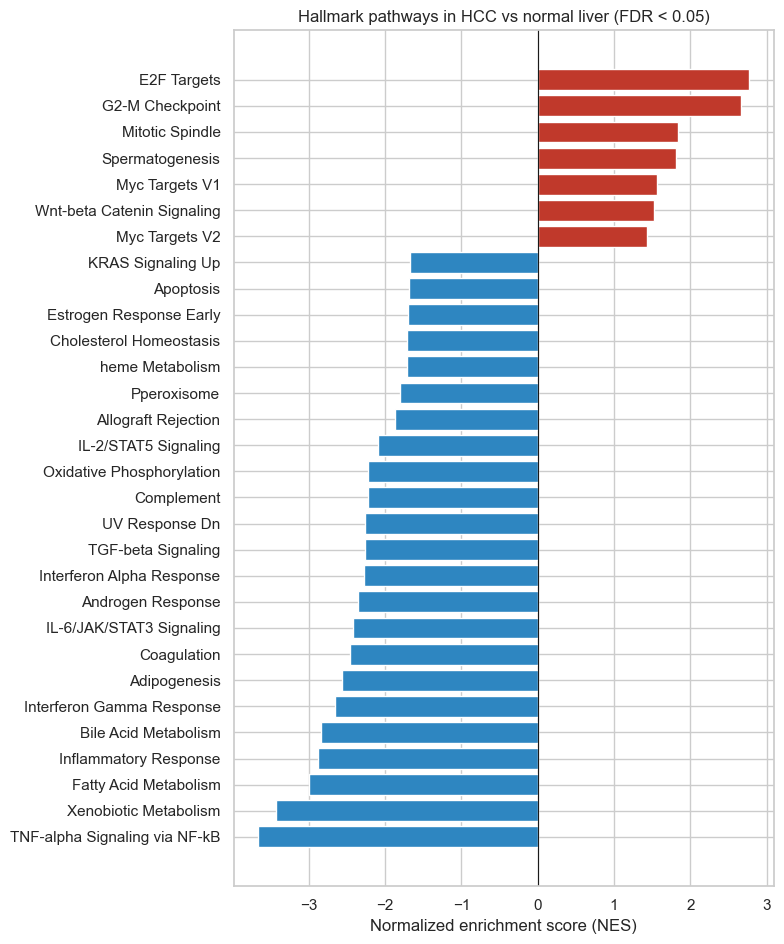

In [6]:
plot_df = hall.copy()
plot_df["significant"] = plot_df["FDR q-val"] < FDR
plot_df = pd.concat([plot_df[plot_df["significant"]].head(15),
                     plot_df[plot_df["significant"]].tail(15)]).drop_duplicates("Term")
plot_df = plot_df.sort_values("NES")

colors = np.where(plot_df["NES"] > 0, "#c0392b", "#2e86c1")
fig, ax = plt.subplots(figsize=(8, max(4, 0.32 * len(plot_df))))
ax.barh(plot_df["Term"], plot_df["NES"], color=colors)
ax.axvline(0, c="k", lw=.8)
ax.set(xlabel="Normalized enrichment score (NES)", ylabel="",
       title=f"Hallmark pathways in HCC vs normal liver (FDR < {FDR})")
plt.tight_layout(); plt.savefig(FIG / "03_gsea_hallmark.png", dpi=150); plt.show()

### Enrichment plots for the strongest pathways

The classic GSEA picture. **Top panel:** the running score climbs every time we meet a pathway gene while walking down the ranking. **Middle:** black bars mark where the pathway's genes sit in the ranking. A peak on the left = genes bunched at the top = activated in tumor.

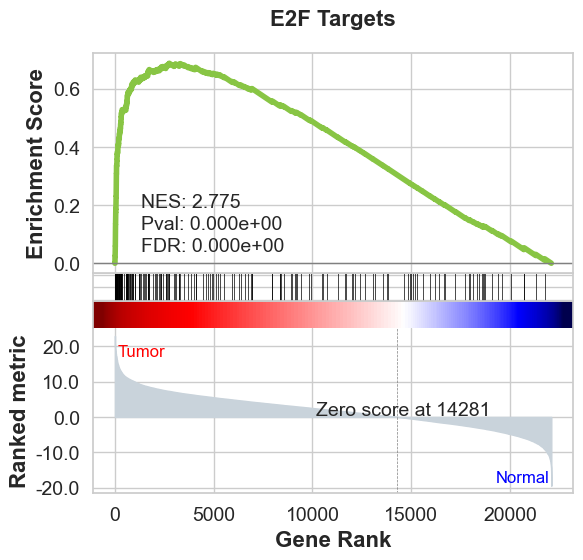

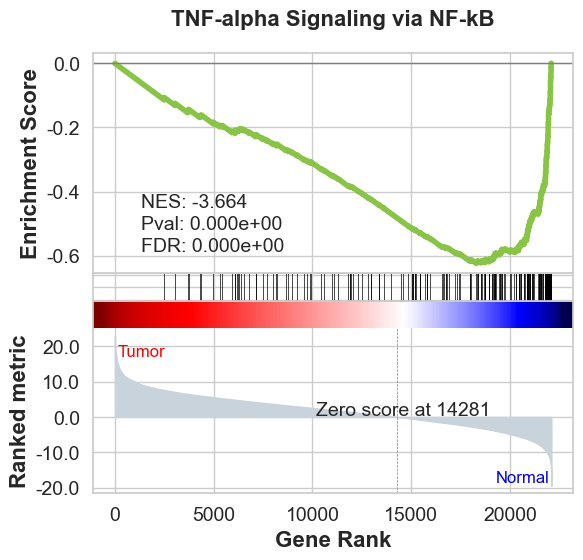

In [7]:
sig_hall = hall[hall["FDR q-val"] < FDR]
top_terms = []
if (sig_hall["NES"] > 0).any():
    top_terms.append(sig_hall.loc[sig_hall["NES"].idxmax(), "Term"])
if (sig_hall["NES"] < 0).any():
    top_terms.append(sig_hall.loc[sig_hall["NES"].idxmin(), "Term"])

nes = hall.set_index("Term")["NES"]
for term in top_terms:
    direction = "up" if nes[term] > 0 else "down"
    axes = gp.gseaplot(rank_metric=gsea.ranking, term=term,
                       pheno_pos="Tumor", pheno_neg="Normal", **gsea.results[term])
    axes[0].figure.savefig(FIG / f"03_gsea_plot_{direction}.png", dpi=150, bbox_inches="tight")
    plt.show()

## 4. ORA on Reactome pathways

Now we take only our **robust** genes and ask, for each Reactome pathway: do we see more of its genes in our list than we'd expect by chance?

**Background** = all ~22,000 genes we tested. This matters: using the whole genome as background would make liver-expressed genes look enriched just because they're expressed in liver.

In [8]:
def run_ora(genes, label):
    enr = gp.enrich(gene_list=list(genes), gene_sets=reactome, background=background,
                    outdir=None, no_plot=True, verbose=False)
    df = enr.results.copy()
    df["direction"] = label
    df["n_hits"] = df["Overlap"].str.split("/").str[0].astype(int)
    return df.sort_values("Adjusted P-value")

ora_up = run_ora(up_genes, "up in tumor")
ora_down = run_ora(down_genes, "down in tumor")
ora_up.to_csv(RES / "ora_reactome_up.csv", index=False)
ora_down.to_csv(RES / "ora_reactome_down.csv", index=False)

print(f"Reactome pathways enriched (adj. p < {FDR}): "
      f"{(ora_up['Adjusted P-value'] < FDR).sum()} in up genes, "
      f"{(ora_down['Adjusted P-value'] < FDR).sum()} in down genes")
ora_up[["Term", "Overlap", "Adjusted P-value", "Odds Ratio"]].head(15).round(4)

Reactome pathways enriched (adj. p < 0.05): 82 in up genes, 122 in down genes


,Term,Overlap,Adjusted P-value,Odds Ratio
141,Cell Cycle Checkpoints R-HSA-69620,71/255,0.0,4.3956
142,Cell Cycle R-HSA-1640170,124/620,0.0,2.8864
143,"Cell Cycle, Mitotic R-HSA-69278",103/496,0.0,3.0066
870,Resolution Of Sister Chromatid Cohesion R-HSA-...,38/103,0.0,6.5837
1099,Unattached Kinetochores Signal Amplification V...,34/90,0.0,6.8273
286,EML4 And NUDC In Mitotic Spindle Formation R-H...,34/94,0.0,6.3747
588,Mitotic Spindle Checkpoint R-HSA-69618,36/107,0.0,5.7099
1102,Unwinding Of DNA R-HSA-176974,11/11,0.0,254.6343
781,RHO GTPases Activate Formins R-HSA-5663220,35/115,0.0,4.9276
586,Mitotic Prometaphase R-HSA-68877,44/183,0.0,3.5718


In [9]:
ora_down[["Term", "Overlap", "Adjusted P-value", "Odds Ratio"]].head(15).round(4)

,Term,Overlap,Adjusted P-value,Odds Ratio
92,Biological Oxidations R-HSA-211859,51/199,0.0,5.9263
265,Drug ADME R-HSA-9748784,30/88,0.0,8.7955
668,Phase I - Functionalization Of Compounds R-HSA...,29/95,0.0,7.4748
179,Complement Cascade R-HSA-166658,21/54,0.0,10.7614
515,Metabolism Of Amino Acids And Derivatives R-HS...,55/347,0.0,3.2305
188,Creation Of C4 And C2 Activators R-HSA-166786,11/14,0.0,54.7326
90,Binding And Uptake Of Ligands By Scavenger Rec...,17/40,0.0,12.4525
311,Fatty Acid Metabolism R-HSA-8978868,34/162,0.0,4.5288
522,Metabolism Of Lipids R-HSA-556833,82/681,0.0,2.3608
67,Aspirin ADME R-HSA-9749641,16/39,0.0,11.7315


### ORA dot plot

- **x:** −log10 adjusted p-value (further right = more significant)
- **dot size:** how many of our genes are in the pathway
- **color:** odds ratio (how many times more than expected by chance)

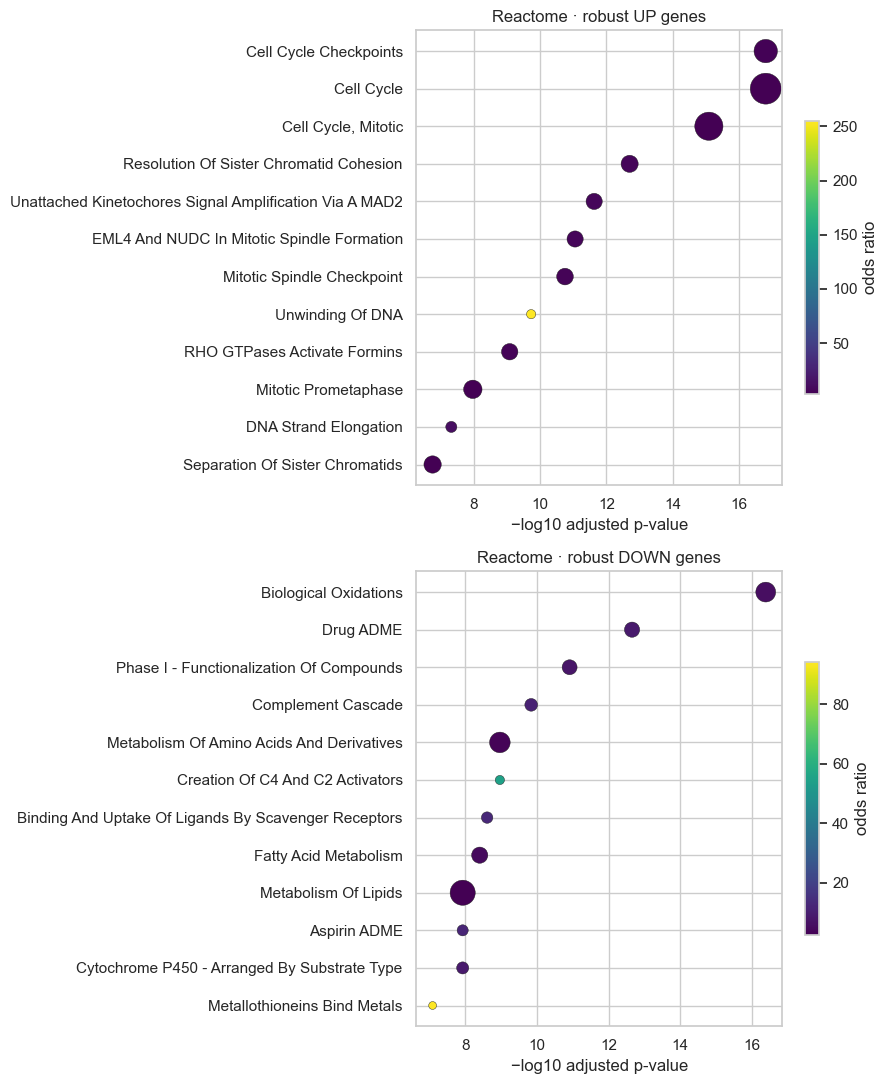

In [10]:
def ora_panel(df, ax, title, n=12):
    d = df[df["Adjusted P-value"] < FDR].head(n).copy()
    if d.empty:
        ax.text(.5, .5, "no significant pathways", ha="center", transform=ax.transAxes); ax.set_title(title); return
    d["neglog10"] = -np.log10(d["Adjusted P-value"].clip(lower=1e-300))
    d["Term"] = d["Term"].str.replace(r" R-HSA-\d+$", "", regex=True).str.slice(0, 55)
    d = d.iloc[::-1]
    sc = ax.scatter(d["neglog10"], d["Term"], s=d["n_hits"] * 4, c=d["Odds Ratio"],
                    cmap="viridis", edgecolor="k", lw=.3)
    plt.colorbar(sc, ax=ax, label="odds ratio", shrink=.6)
    ax.set(xlabel="−log10 adjusted p-value", title=title)

fig, axes = plt.subplots(2, 1, figsize=(9, 11))
ora_panel(ora_up, axes[0], "Reactome · robust UP genes")
ora_panel(ora_down, axes[1], "Reactome · robust DOWN genes")
plt.tight_layout(); plt.savefig(FIG / "03_ora_reactome.png", dpi=150, bbox_inches="tight"); plt.show()

## 5. Link pathways back to candidate genes

The **leading edge** of a GSEA result = the pathway genes that drive the signal (the ones before the peak). For each robust upregulated gene, we note which significant activated Hallmark pathways it drives. This tells us *why* a candidate might matter when we rank drug targets later.

In [11]:
cands = pd.read_csv(RES / "de_upregulated_robust.csv", index_col=0)

act = hall[(hall["FDR q-val"] < FDR) & (hall["NES"] > 0)]
gene_to_paths = {}
for _, row in act.iterrows():
    for g in str(row["Lead_genes"]).split(";"):
        gene_to_paths.setdefault(g, []).append(row["Term"])

cands["hallmark_pathways"] = cands["gene"].map(lambda g: "; ".join(gene_to_paths.get(g, [])))
cands.to_csv(RES / "candidates_with_pathways.csv")

n_linked = (cands["hallmark_pathways"] != "").sum()
print(f"{n_linked:,} of {len(cands):,} robust up genes drive at least one activated Hallmark pathway")
cands[cands["hallmark_pathways"] != ""][["gene", "log2FC", "padj", "hallmark_pathways"]].head(20).round(3)

134 of 1,842 robust up genes drive at least one activated Hallmark pathway


,gene,log2FC,padj,hallmark_pathways
gene_id,,,,
ENSG00000198033.12,TUBA3C,7.241,0.0,Spermatogenesis
ENSG00000107984.10,DKK1,5.759,0.0,Wnt-beta Catenin Signaling
ENSG00000104371.5,DKK4,4.849,0.0,Wnt-beta Catenin Signaling
ENSG00000128683.14,GAD1,4.749,0.0,Spermatogenesis
ENSG00000138798.13,EGF,4.652,0.0,G2-M Checkpoint
ENSG00000101057.16,MYBL2,4.536,0.0,E2F Targets; G2-M Checkpoint
ENSG00000117399.14,CDC20,4.250,0.0,E2F Targets; G2-M Checkpoint; Myc Targets V1
ENSG00000142583.18,SLC2A5,4.176,0.0,Spermatogenesis
ENSG00000135451.13,TROAP,4.144,0.0,G2-M Checkpoint


## Notes

- **Gene set libraries:** MSigDB_Hallmark_2020 (GSEA), Reactome via Enrichr (ORA)
- **Hallmark GSEA:** 7 activated, 23 suppressed pathways (FDR < 0.05)
- **Top activated:** E2F Targets (NES 2.78), G2-M Checkpoint, Mitotic Spindle, Myc Targets V1/V2, Wnt-beta Catenin Signaling, Spermatogenesis (overlaps with cell division + cancer-testis genes)
- **Top suppressed:** TNF-alpha/NF-kB (strongest), Xenobiotic Metabolism, Fatty Acid Metabolism, Bile Acid Metabolism, Inflammatory Response, Interferon Gamma, Coagulation, Complement
- **Reactome ORA:** 82 pathways enriched in up genes, 122 in down genes
  - Up: cell cycle checkpoints, mitosis, kinetochores; all 11 MCM helicase genes up (Unwinding of DNA, odds ratio 254)
  - Down: biological oxidations, drug ADME, CYP450, lipid and amino acid metabolism, complement, metallothioneins
- **Candidates linked to activated Hallmark pathways:** 134 of 1,842 (e.g. DKK1, DKK4, EGF, MYBL2, CDC20)
- **Matches known HCC biology?** Yes: proliferation, MYC and Wnt/beta-catenin up; hepatocyte metabolic functions down.
- **Surprising:** immune/inflammatory pathways are suppressed in tumors. Likely due to immune-rich diseased adjacent liver and tissue-handling stress in normal samples (immediate-early gene CSRNP1 among the most down genes). MAP2K1 (MEK1) mRNA is down, though MAPK signaling is usually activated at the protein level, not by more mRNA.